## 随机森林
我们可以将这个词拆成 **随机** 和 **森林** 两个部分来理解
### 1.森林：
工作与生活中，我们常会采用多人共同商讨问题并进行投票表决的方式来避免个人判断的主观性，提高决策的客观性与科学性。

“森林”的基本单位是**决策树**，单棵决策树本身的判断和单个人决策一样具有主观性（欠拟合与过拟合），那么我们也可以考虑采用同样的方法来一定程度地规避这种问题，即训练**多棵树**（森林）并让他们分别做判断，最后靠**投票**来决定最终的分类（或回归）结果，这也就是随机森林的核心思想


### 2.随机：
我们在网络中常能听见“信息茧房”一类的说法，而现在一个常见的场景就是关于视频平台的推荐算法影响下，我们刷到的大多是我们想看的，或与我们的某些理念契合的内容，这个过程中就是一个给自己织起茧房的过程，我们逐渐无法听见茧房外异己的声音，反而是在自己的回音中不断加强固有的观念。

随机森林也是一样的，如果森林中的树基本上都是一样的，那么“构建森林，投票表决”的行为将失去意义。所以，让这些决策树不一样成了我们引入随机性的直接目的。

#### 随机性主要来自以下两点：
- 数据随机：自助采样（Bootstrap）：
每棵树不是在整个训练集上训练，而是在随机有放回地抽出来的一个子集上训练（约63%的原始样本，剩下的叫“袋外样本”OOB）。这样每棵树看到的“世界”都不一样。
- 特征随机：随机子空间：
在每个节点分裂时，不是在所有特征里挑最好的那个，而是先随机抽一个子集的特征（如总特征的√n），再在这个子集里挑最佳分裂点。这打破了树树之间的相关性，让“投票”更有代表性。

整体来看，随机森林牺牲了单棵决策树所具有的快速的**训练与推理速率**和**强可解释性**，但通常可以获得更好的预测和泛化能力

问题：
请使用所给数据集中的数据来训练模型，使其可以在输入某一乘客的各项特征后判断其是否从泰坦尼克号事件中幸存了下来

数据集来源：https://www.kaggle.com/datasets/heptapod/titanic

> 为了方便与单棵决策树进行比较，这里采用了相同的问题
>
> 但也需要注意的是，由于这个**数据集样本和特征数都较少**，这会弱化随机的效果，最终的预测能力实际上和决策树差不多

In [132]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

### **1.读取数据集并获得其基本信息**

In [133]:
df = pd.read_csv('train_and_test2.csv')
print(df.columns.to_list())

['Passengerid', 'Age', 'Fare', 'Sex', 'sibsp', 'zero', 'zero.1', 'zero.2', 'zero.3', 'zero.4', 'zero.5', 'zero.6', 'Parch', 'zero.7', 'zero.8', 'zero.9', 'zero.10', 'zero.11', 'zero.12', 'zero.13', 'zero.14', 'Pclass', 'zero.15', 'zero.16', 'Embarked', 'zero.17', 'zero.18', '2urvived']


### **2.进行数据预处理**
由于决策树对于数据的尺度并不敏感，故这里之对缺失值进行处理

#### 2.1 提取有效数据列并查看数据缺失情况

In [134]:
features_target = ['Age', 'Fare', 'Sex', 'sibsp', 'Parch', 'Pclass', 'Embarked', '2urvived']
data = df[features_target]
nan = data.isnull().sum()
print(f"数据确实情况为：\n{nan}")

数据确实情况为：
Age         0
Fare        0
Sex         0
sibsp       0
Parch       0
Pclass      0
Embarked    2
2urvived    0
dtype: int64


#### 2.2 填充缺失数据

In [135]:
most_frequent_embarked = data['Embarked'].mode()[0]
data['Embarked'] = data['Embarked'].fillna(most_frequent_embarked, inplace = False)
print(data.describe())

<bound method NDFrame.describe of        Age      Fare  Sex  sibsp  Parch  Pclass  Embarked  2urvived
0     22.0    7.2500    0      1      0       3       2.0         0
1     38.0   71.2833    1      1      0       1       0.0         1
2     26.0    7.9250    1      0      0       3       2.0         1
3     35.0   53.1000    1      1      0       1       2.0         1
4     35.0    8.0500    0      0      0       3       2.0         0
...    ...       ...  ...    ...    ...     ...       ...       ...
1304  28.0    8.0500    0      0      0       3       2.0         0
1305  39.0  108.9000    1      0      0       1       0.0         0
1306  38.5    7.2500    0      0      0       3       2.0         0
1307  28.0    8.0500    0      0      0       3       2.0         0
1308  28.0   22.3583    0      1      1       3       0.0         0

[1309 rows x 8 columns]>


### **3.对数据集进行划分**

In [136]:
X = data.iloc[:, :-1]
y = data.iloc[:, -1]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

### **4.训练模型并进行预测**
我们这里采用 GridSearchCV 方法来寻找最合适的模型参数

也就是根据我们给的 param_grid 生成一张网格（grid），然后便遍历网格上所有可能的组合并取最终效果最好的一组参数作为最优参数

In [137]:
from sklearn.model_selection import GridSearchCV

#通常来说树的数量（n_estimator）都是100起步，但由于本例中训练集样本过少，树过多反倒不一定有好处
#其他参数都和决策树一样
rf = RandomForestClassifier(random_state = 0, oob_score = True)     # oob_score项用来设定是否需要计算该分数
param_grid = {'n_estimators': [15, 25, 50],
              'max_depth': [None, 5, 10, 15],
              'min_samples_split': [2, 5, 10],
              'min_samples_leaf': [1, 3, 5],
              'criterion': ['gini', 'entropy'],
              'max_features': ['sqrt', None]
              }
grid_searcher = GridSearchCV(estimator = rf,
                             param_grid = param_grid,
                             cv = 5,    #做 5 次交叉验证
                             scoring = 'accuracy',
                             n_jobs = -1    #使用所有 cpu 核心进行并行运算
                             )

grid_searcher.fit(X_train, y_train)
print(f"最佳参数：{grid_searcher.best_params_}")
print(f"最佳交叉验证分数：{grid_searcher.best_score_}")

best_rf = grid_searcher.best_estimator_
y_pred = best_rf.predict(X_test)

最佳参数：{'criterion': 'entropy', 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 25}
最佳交叉验证分数：0.8022920938710412


### **5.评估模型训练效果**

In [138]:
# 混淆矩阵
from sklearn.metrics import confusion_matrix, classification_report
cm = confusion_matrix(y_test, y_pred)
print(cm)
TN, FP = cm[0, 0], cm[0, 1]
FN, TP = cm[1, 0], cm[1, 1]

[[160  17]
 [ 48  37]]


In [139]:
# accuracy, recall, precision, f1-score
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.90      0.83       177
           1       0.69      0.44      0.53        85

    accuracy                           0.75       262
   macro avg       0.73      0.67      0.68       262
weighted avg       0.74      0.75      0.73       262



**袋外误差**（OOB Error）：免验证集的评估
因为每棵树只用了约63%的样本，剩下的约37%样本（OOB）没被这棵树“看见”。我们可以用这些 OOB 样本来评估模型的泛化能力。

对每个样本，找出所有“没把它当训练数据”的树，只让这些树投票，然后看投得对不对。
整体算下来就是袋外误差，近似等于交叉验证的结果，无需单独划验证集

因此该参数的效力实际上和测试集正确率相当

In [140]:
print(f"OOB准确率：{best_rf.oob_score_}")

OOB准确率：0.789875835721108


### **6.训练结果可视化**

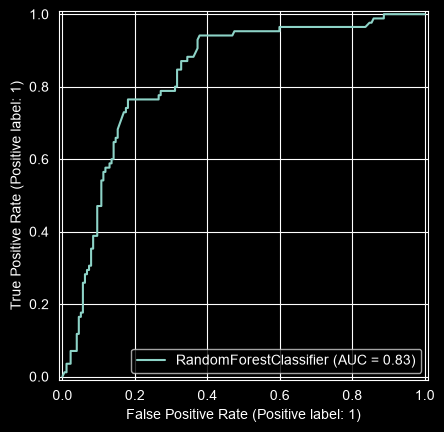

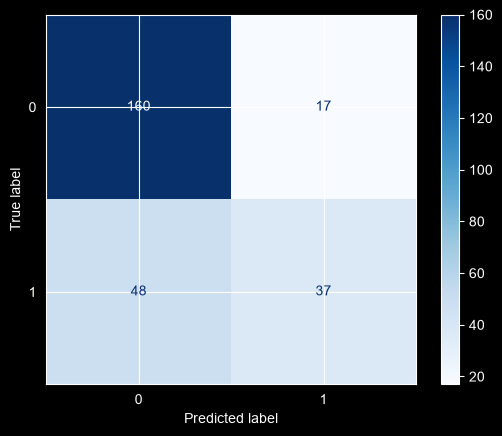

In [141]:
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay

# ROC 曲线
RocCurveDisplay.from_estimator(best_rf, X_test, y_test)
plt.show('rf_roc_curve.png')

# 混淆矩阵热力图
ConfusionMatrixDisplay.from_estimator(best_rf, X_test, y_test, cmap='Blues')
plt.show('rf_confusion_matrix.png')